## M1L2SC1: Preprocessing Real-World Data for Machine Learning

### Step 1: Understand Your Data

In [ ]:
import pandas as pd

# Example dataset
data = {
    'ID': [1, 2, 3, 4, 5],
    'Country': ['USA', 'Canada', 'Mexico', 'Canada', 'USA'],
    'Age': [25, 30, 22, None, 28],
    'Salary': [50000, None, 45000, 52000, 49000]
}
df = pd.DataFrame(data)

print("Dataset Overview")
print(df.info())
print("\nSample Data:")
print(df.head())

Dataset Overview
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   ID       5 non-null      int64  
 1   Country  5 non-null      object 
 2   Age      4 non-null      float64
 3   Salary   4 non-null      float64
dtypes: float64(2), int64(1), object(1)
memory usage: 292.0+ bytes
None

Sample Data:
   ID Country   Age   Salary
0   1     USA  25.0  50000.0
1   2  Canada  30.0      NaN
2   3  Mexico  22.0  45000.0
3   4  Canada   NaN  52000.0
4   5     USA  28.0  49000.0


### Step 2: Handle Missing Data

In [ ]:
# Impute missing values for Age with mean
df['Age'].fillna(df['Age'].mean(), inplace=True)

# Drop rows with missing Salary values
df.dropna(subset=['Salary'], inplace=True)

print("\nData After Handling Missing Values:")
print(df)


Data After Handling Missing Values:
   ID Country    Age   Salary
0   1     USA  25.00  50000.0
2   3  Mexico  22.00  45000.0
3   4  Canada  26.25  52000.0
4   5     USA  28.00  49000.0


<ipython-input-4-3591751451>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)


### Step 3: Normalize and Scale Data


In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Min-Max normalization for Age and Salary
scaler = MinMaxScaler()
df[['Age', 'Salary']] = scaler.fit_transform(df[['Age', 'Salary']])

print("\nData After Normalization:")
print(df)


Data After Normalization:
   ID Country       Age    Salary
0   1     USA  0.500000  0.714286
2   3  Mexico  0.000000  0.000000
3   4  Canada  0.708333  1.000000
4   5     USA  1.000000  0.571429


### Step 4: Encode Categorical Variables

In [ ]:
# One-hot encoding for the 'Country' feature
df = pd.get_dummies(df, columns=['Country'])

print("\nData After Encoding Categorical Variables:")
print(df)


Data After Encoding Categorical Variables:
   ID       Age    Salary  Country_Canada  Country_Mexico  Country_USA
0   1  0.500000  0.714286           False           False         True
2   3  0.000000  0.000000           False            True        False
3   4  0.708333  1.000000            True           False        False
4   5  1.000000  0.571429           False           False         True


### Step 5: Detect and Treat Outliers

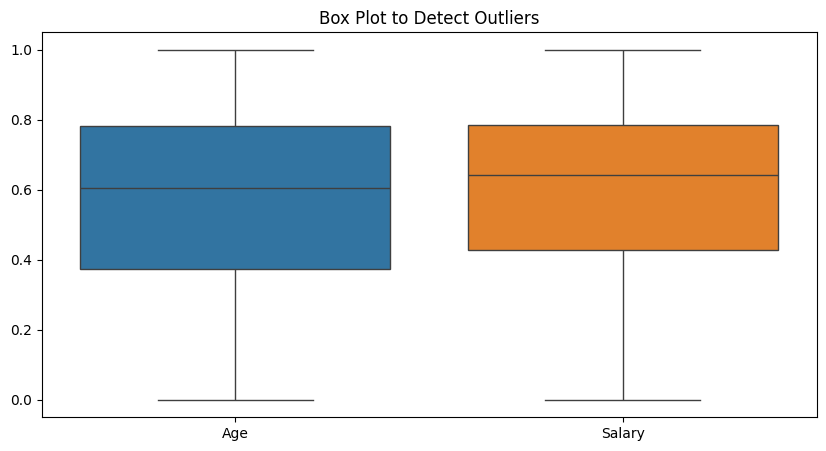


Data After Treating Outliers:
   ID       Age    Salary  Country_Canada  Country_Mexico  Country_USA
0   1  0.500000  0.714286           False           False         True
2   3  0.000000  0.000000           False            True        False
3   4  0.708333  1.000000            True           False        False
4   5  1.000000  0.571429           False           False         True


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Box plot to identify outliers
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[['Age', 'Salary']])
plt.title("Box Plot to Detect Outliers")
plt.show()

# Treating outliers (example: removing entries with Salary outliers)
Q1 = df['Salary'].quantile(0.25)
Q3 = df['Salary'].quantile(0.75)
IQR = Q3 - Q1
outlier_filter = ((df['Salary'] >= (Q1 - 1.5 * IQR)) & (df['Salary'] <= (Q3 + 1.5 * IQR)))
df = df[outlier_filter]

print("\nData After Treating Outliers:")
print(df)

### Step 6: Feature Extraction and Selection

In [ ]:
from sklearn.feature_selection import VarianceThreshold

# Example of feature selection (variance threshold)
selector = VarianceThreshold(threshold=0.1)
df_selected = selector.fit_transform(df)

print("\nData After Feature Selection:")
print(pd.DataFrame(df_selected, columns=df.columns[selector.get_support()]))


Data After Feature Selection:
    ID       Age    Salary  Country_Canada  Country_Mexico  Country_USA
0  1.0  0.500000  0.714286             0.0             0.0          1.0
1  3.0  0.000000  0.000000             0.0             1.0          0.0
2  4.0  0.708333  1.000000             1.0             0.0          0.0
3  5.0  1.000000  0.571429             0.0             0.0          1.0
